# Pipeline stage 2: characterization of the predicted phage-encoded acetyltransferases

### Stage 2.2: impact of the expression of predicted phage-encoded acetyltransferases on *P. aeruginosa* growth

In our research, we investigated bacterial growth upon heterologous expression of the predicted phage-encoded acetyltransferase proteins, to assess the biological relevance of the diverse predicted acetyltransferases. In this notebook, we will parse and visualize those results.

**Goals:**
* Parse OD600 measurements.
* Visualize OD600 measurements.

**Requires:**
* OD600 measurement files OD600_plate1.tsv and OD600_plate2.tsv stored in data/ : tab-separated files containing the OD600 measurements

**Generates:**
* PROTEIN_OD600.svg for all selected phage-encoded acetyltransferase PROTEINs : lineplots visualizing the OD600 measurements of *P. aeruginosa* PAO1 strains carrying a single-copy, lac-inducible mini-Tn7T insertion of the indicated predicted phage-encoded acetyltransferases, as measured during the 24-hour liquid growth assay. 

#### General settings, imports, variables and environments

Conda environment: viral_act_growth

Created with `conda create -n viral_act_growth python=3.10`. Then installed  `jupyter notebook`, `pandas` through conda (command `conda install`), and `seaborn` through pip (command below).

In [1]:
!pip install seaborn

In [2]:
!conda list --explicit

# This file may be used to create an environment using:
# $ conda create --name <env> --file <this file>
# platform: win-64
# created-by: conda 24.11.3
@EXPLICIT
https://conda.anaconda.org/conda-forge/noarch/ca-certificates-2026.4.22-h4c7d964_0.conda
https://conda.anaconda.org/conda-forge/win-64/onemkl-license-2026.0.0-h57928b3_907.conda
https://conda.anaconda.org/conda-forge/noarch/python_abi-3.10-8_cp310.conda
https://conda.anaconda.org/conda-forge/noarch/tzdata-2025c-hc9c84f9_1.conda
https://conda.anaconda.org/conda-forge/win-64/ucrt-10.0.26100.0-h57928b3_0.conda
https://conda.anaconda.org/conda-forge/win-64/winpty-0.4.3-4.tar.bz2
https://conda.anaconda.org/conda-forge/win-64/libwinpthread-12.0.0.r4.gg4f2fc60ca-h57928b3_10.conda
https://conda.anaconda.org/conda-forge/win-64/vcomp14-14.51.36231-h1b9f54f_37.conda
https://conda.anaconda.org/conda-forge/win-64/vc14_runtime-14.51.36231-h1b9f54f_37.conda
https://conda.anaconda.org/conda-forge/win-64/vc-14.5-h1b7c187_37.conda
https://conda

In [3]:
# imports 
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# clear reference to different directories
pipeline_char_dir = os.getcwd()
master_dir = os.path.abspath(os.path.join(pipeline_char_dir, os.pardir, os.pardir))

In [ ]:
# creating a directory for all the data we will generate
os.mkdir(os.path.join(pipeline_char_dir, "b_growth"))

#### Goal 1 : parse OD600 measurements

Let's first read in the different tables containing all the OD600 measurement data.

In [5]:
# reading in the data as is
OD600_plate1 = pd.read_csv(os.path.join(pipeline_char_dir, "b_growth", "data", "OD600_plate1.tsv"), sep = "\t", header = None)
OD600_plate2 = pd.read_csv(os.path.join(pipeline_char_dir, "b_growth", "data", "OD600_plate2.tsv"), sep = "\t", header = None)

In [6]:
# function to parse the plate data
def parse_plate(df, plate_name):
    # extract the header rows
    well_ids = df.iloc[0].copy()
    conditions = df.iloc[1].copy()
    # extract the data rows
    data = df.iloc[2:].copy()
    # fix column names
    well_ids.iloc[0] = "Type" # this column will not be used (it just says 'Raw Data (600)'), but we need a name for it
    well_ids.iloc[1] = "Time"
    data.columns = well_ids
    # drop useless column
    data = data.drop(columns = "Type")
    # convert OD values to floats
    for col in data.columns[1:]:
        data[col] = data[col].str.replace(",", ".").astype(float)
    # function to convert time to floats (in hours)
    def convert_time(t):
        t = str(t).strip()
        if "h" in t:
            parts = t.replace(" min", "").split(" h")
            hours = int(parts[0])
            if len(parts) > 1 and parts[1].strip() != "":
                minutes = int(parts[1])
            else:
                minutes = 0
            return hours + minutes / 60
        return None
    # actually convert the time
    data["Time_h"] = data["Time"].apply(convert_time)

    # now melt the data into the long format
    long_df = data.melt(
        id_vars=["Time", "Time_h"],
        var_name="Well",
        value_name="OD600"
    )

    # map the well IDs to conditions
    condition_map = dict(zip(well_ids, conditions))
    long_df["Condition"] = long_df["Well"].map(condition_map)
    # extract the protein and induction status from the condition
    long_df["Induced"] = long_df["Condition"].str.contains(" I").map({True: "Induced", False: "Non-induced"})
    long_df["Protein"] = long_df["Condition"].str.replace(" NI| I", "", regex = True)
    # add metadata to have different plates
    long_df["Plate"] = plate_name

    return long_df

In [7]:
# parse the plates
OD600_plate1_long = parse_plate(OD600_plate1, "plate1")
OD600_plate2_long = parse_plate(OD600_plate2, "plate2")
# remove unused columns
to_remove = ["Sample X345", "Sample X346", "Sample X347", "Sample X348", "Sample X349", "Sample X350", "Sample X351", "Sample X352"]
OD600_plate2_long = OD600_plate2_long[~(OD600_plate2_long["Condition"].isin(to_remove))]
# combine the plates
OD600_long = pd.concat([OD600_plate1_long, OD600_plate2_long], ignore_index=True)
# make sure we keep the empty controls per plate separate by adding the plate name to the protein name for the empty controls
OD600_long["Protein"] = OD600_long.apply(lambda row: f"{row['Protein']}_{row['Plate']}" if row["Protein"] == "empty" else row["Protein"],
                                        axis=1)
OD600_long

,Time,Time_h,Well,OD600,Condition,Induced,Protein,Plate
0,0 h,0.00,A01,0.384,empty NI,Non-induced,empty_plate1,plate1
1,0 h 15 min,0.25,A01,0.409,empty NI,Non-induced,empty_plate1,plate1
2,0 h 30 min,0.50,A01,0.440,empty NI,Non-induced,empty_plate1,plate1
3,0 h 45 min,0.75,A01,0.471,empty NI,Non-induced,empty_plate1,plate1
4,1 h,1.00,A01,0.505,empty NI,Non-induced,empty_plate1,plate1
...,...,...,...,...,...,...,...,...
16291,23 h,23.00,H10,2.120,ZC01_gp11 I,Induced,ZC01_gp11,plate2
16292,23 h 15 min,23.25,H10,2.118,ZC01_gp11 I,Induced,ZC01_gp11,plate2
16293,23 h 30 min,23.50,H10,2.086,ZC01_gp11 I,Induced,ZC01_gp11,plate2
16294,23 h 45 min,23.75,H10,2.123,ZC01_gp11 I,Induced,ZC01_gp11,plate2


#### Goal 2 : visualize OD600 measurements

Let's now plot this data.

In [8]:
# color palette for the proteins, consistent with class (like in figure 1)
protein_palette = {
    # class Ia examples
    "AUS531phi_gp40": "#175779", "BR153a_gp4": "#175779", "EL_gp137": "#175779", "EL_gp152": "#175779", 
    "LUZ19_gp13": "#175779", "PA1C_gp22": "#175779", "PAE2_gp12": "#175779", "SA22_gp16": "#175779", "ZC01_gp11": "#175779", 
    # class Ib examples
    "IME180_gp15": "#2f7ca3", 
    # class Ic examples
    "PA1C_gp320": "#5fa3c0",
    # class Ie examples
    "JD024_gp57": "#4a8fb2",
    # class If examples
    "MPK6_gp13": "#77b5cd",
    # class IIa examples
    "LKA1_gp40": "#c98a9a",
    # class IIb examples
    "LUZ19_gp28": "#b8657a", "PT2_gp28": "#b8657a",
    # class III examples
    "30-2_gp303" : "#6FA873", "30-2_gp343" : "#6FA873", 
    # non-GNAT class
    "YA3_gp20": "#CF7A4D"
}

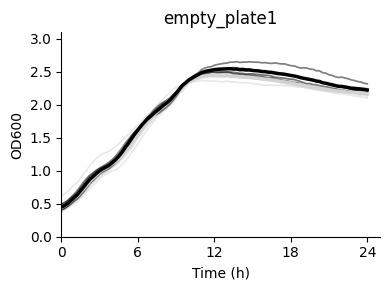

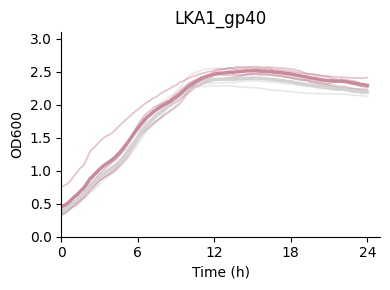

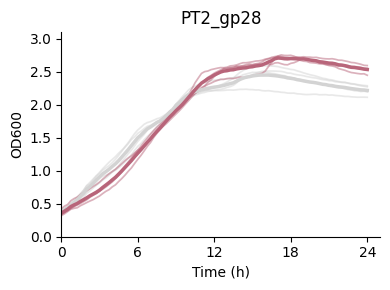

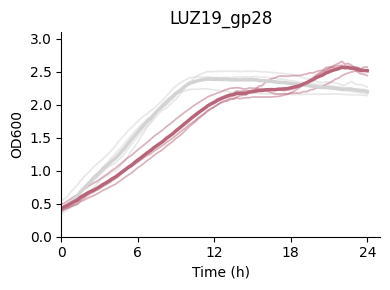

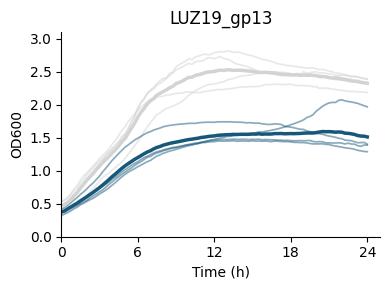

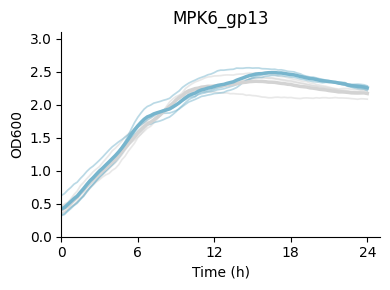

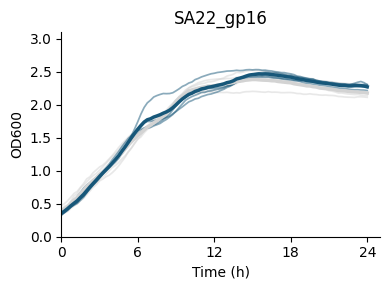

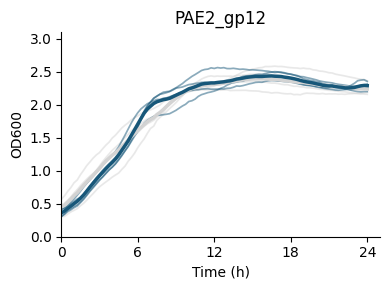

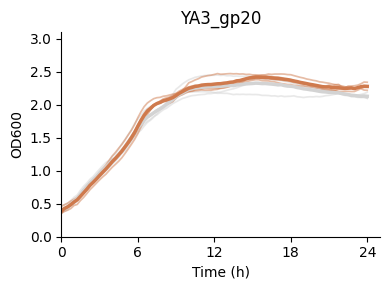

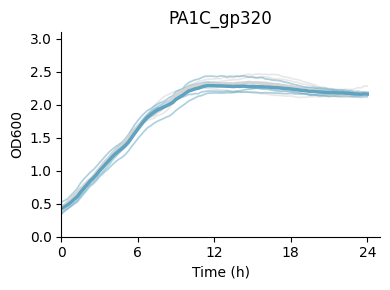

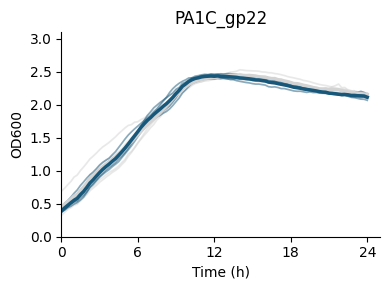

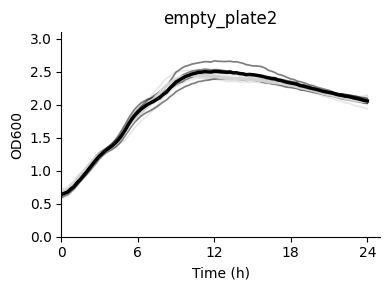

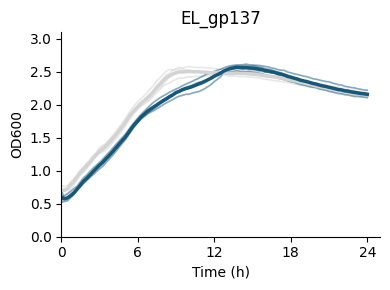

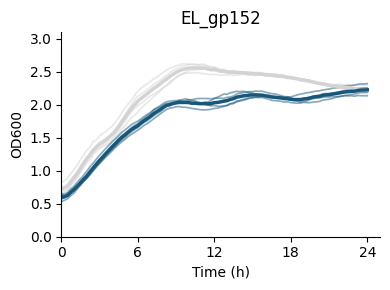

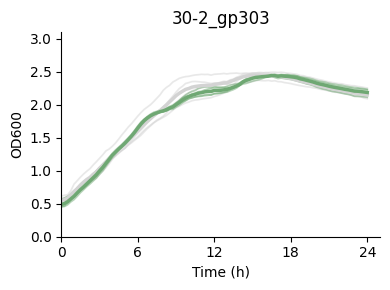

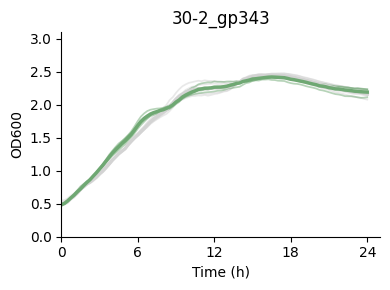

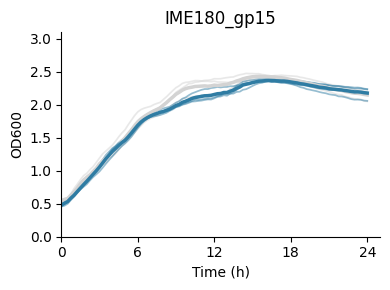

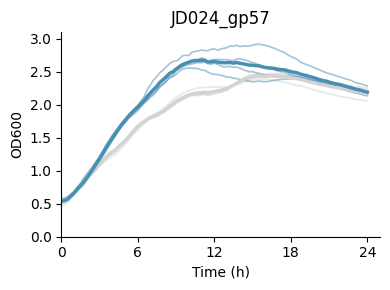

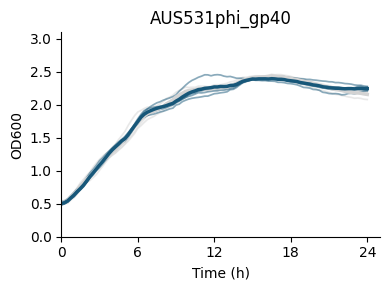

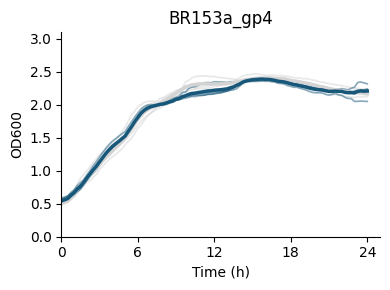

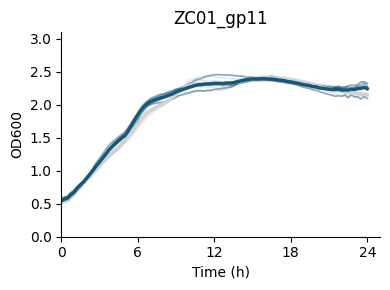

In [9]:
for protein in OD600_long["Protein"].unique():
    # extract the subset of data for the current protein
    subset = OD600_long[OD600_long["Protein"] == protein]
    # create plot
    fig, ax = plt.subplots(figsize=(4, 3))
    protein_color = protein_palette.get(protein, "black")
    # draw the individual replicates
    sns.lineplot(
        data = subset,
        x = "Time_h",
        y = "OD600",
        hue = "Induced",
        units = "Well",
        estimator = None,        
        alpha = 0.5,             
        linewidth = 1.25,
        palette = {"Non-induced": "lightgrey", "Induced": protein_color},
        legend = False
    )
    # also put the mean as a thick line on the plot
    sns.lineplot(
        data=subset,
        x="Time_h",
        y="OD600",
        hue="Induced",
        estimator="mean",
        errorbar=None,
        linewidth=2.5,        
        palette = {"Non-induced": "lightgrey", "Induced": protein_color},
        legend=False
    )

    ax.set_title(protein)
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("OD600")
    # minimal style with correct axis limits and ticks
    sns.despine()
    ax.set_xlim(0, 25)
    ax.set_ylim(0, 3.1)
    ax = plt.gca()
    ax.set_xticks(np.arange(0, 25, 6))
    ax.set_yticks(np.arange(0, 3.1, 0.5))
    plt.tight_layout()
    
    plt.show()

    # to save the plot without labels, uncomment this
    ax.set_title("")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelbottom = False, labelleft = False)
    fig.savefig(os.path.join(pipeline_char_dir, "b_growth", f"{protein}_OD600.svg"), format = "svg", transparent = True)